In [2]:
'''
In this file, we will work on implementing the Zermelo problem, with some new changes:
- No obstacles
- The state evolution will be deterministic, as it is when one specifies a flight trajectory
- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity
- Of course, it may be difficult to balance this with the cost associated to reaching the destination
- We will set harsh constraints on the maximum and minimum velocities via a sigmoid
- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet

It will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)
'''

'\nIn this file, we will work on implementing the Zermelo problem, with some new changes:\n- No obstacles\n- The state evolution will be deterministic, as it is when one specifies a flight trajectory\n- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity\n- Of course, it may be difficult to balance this with the cost associated to reaching the destination\n- We will set harsh constraints on the maximum and minimum velocities via a sigmoid\n- We will model wind via a Brownian bridge from -W to +W\n'

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os

In [167]:
# will aim to traverse from (-10, 0) to (10, 0).
# speed of reference trajectories will be 2 units per time step, thus we use time horizon of 10 steps
# will experiment with values for w_min and w_max

def brownian_bridge_from_bm(a, b, T, time_step):
    """
    Simulate Brownian bridge on provided times using transform of a Brownian motion.
    times: array of times in [0,T], must include 0 and T (sorted).
    Returns array of bridge values at times.
    """
    total_steps = int(T / time_step) 
    # simulate BM increments
    increments = np.random.normal(loc=0.0, scale=np.sqrt(time_step), size = total_steps)
    W = np.zeros(total_steps + 1, dtype=float)
    W[1:] = np.cumsum(increments)
    WT = W[-1]
    # transform to bridge
    times = np.arange(0, T + time_step, time_step)
    linear = a + (b - a) * (times / T)
    bridge = linear + (W - (times / T) * WT)
    return bridge.astype(np.float32)
    



Text(0.5, 1.0, 'Sample Brownian Bridge winds')

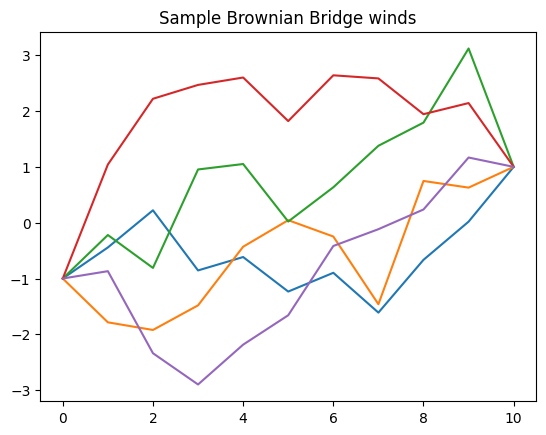

In [168]:
for i in range(5):
    plt.plot(brownian_bridge_from_bm(-1, 1, 10, 1))
plt.title("Sample Brownian Bridge winds")

In [134]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [176]:
# define control NNs
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.Tanh()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled

# loss function (wind cost + terminal cost)
def running_loss(wind_value, velocity):
    zeros_vec = torch.zeros_like(wind_value, device = device)
    wind_vector = torch.cat([zeros_vec, wind_value], dim  = 1, device = device)
    wind_cost = torch.abs(velocity - wind_vector) ** 3
    return wind_cost

def terminal_loss(position, target):
    ones_vec = torch.ones_like(position, device = device)
    target_matrix = ones_vec * target
    final_cost = (position - target_matrix) ** 2

def penalising_velocity(velocity, min_speed, max_speed, multiplier):
    speed = torch.norm(velocity, dim = 1, keepdim = True)
    min_cost = torch.sigmoid(- min_speed - speed) 
    max_cost = torch.sigmoid(speed - max_speed)
    return multiplier * (min_cost + max_cost)

# base policy randomiser function
def random_base_policy(num_policies, num_steps, min_angle, max_angle, base_speed):
    angle_matrix = torch.rand((num_policies, num_steps), device = device) * (max_angle - min_angle) + min_angle
    velocities = torch.stack((torch.cos(angle_matrix), torch.sin(angle_matrix)), dim= -1) * base_speed
    return velocities

In [177]:
# visualise trajectories for a set of random base policies
num_policies = 50
num_steps = 10
policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
target = torch.tensor([-10.0, 0.0], device = device)
base_trajectories = torch.zeros((num_policies, num_steps + 1, 2), device = device)
base_trajectories[:, 0, :] = target
# for t in range(num_steps):
#     base_trajectories[:, t + 1, :] = base_trajectories[:, t, :] + policies[:, t, :]
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
trajectories = torch.cumsum(policies, dim = 1) + torch.tensor([-10, 0], device = device)
trajectories = torch.cat((starts, trajectories), dim = 1)

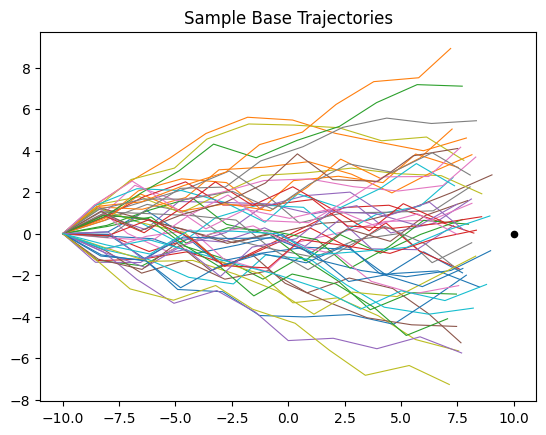

In [178]:
plt.plot(trajectories[:,:,0].cpu().numpy().T, trajectories[:,:,1].cpu().numpy().T, linewidth = 0.8)
plt.title("Sample Base Trajectories")
plt.scatter(10, 0, s = 20, color = "black")
plt.show()

In [179]:
# now, note that our training dataset will be augmented to num_sample * num_policies
def generate_training_data(a, b, T, time_step, n, num_policies):
    training_data = torch.zeros((n * num_policies, int(T / time_step)), device = device)
    for i in range(n):
        bridge = torch.tensor(brownian_bridge_from_bm(a, b, T, time_step)[: -1], device = device)
        bridge = bridge.repeat(num_policies, 1)
        training_data[i * num_policies : (i + 1) * num_policies, :] = bridge
    return training_data

In [180]:
generate_training_data(-1, 1, 10, 1, 5, 3)

tensor([[-1.0000, -0.2675,  0.7928,  1.3201,  0.7744,  0.4939, -0.2070,  0.8381,
          0.0739, -0.5181],
        [-1.0000, -0.2675,  0.7928,  1.3201,  0.7744,  0.4939, -0.2070,  0.8381,
          0.0739, -0.5181],
        [-1.0000, -0.2675,  0.7928,  1.3201,  0.7744,  0.4939, -0.2070,  0.8381,
          0.0739, -0.5181],
        [-1.0000, -2.2562, -1.6921, -2.6615, -2.7822, -2.0585, -0.3906, -0.1350,
         -1.3782, -0.2973],
        [-1.0000, -2.2562, -1.6921, -2.6615, -2.7822, -2.0585, -0.3906, -0.1350,
         -1.3782, -0.2973],
        [-1.0000, -2.2562, -1.6921, -2.6615, -2.7822, -2.0585, -0.3906, -0.1350,
         -1.3782, -0.2973],
        [-1.0000, -0.8098, -0.0080, -0.1566, -0.4877, -0.5405, -0.1088,  0.1333,
          1.6588,  1.3313],
        [-1.0000, -0.8098, -0.0080, -0.1566, -0.4877, -0.5405, -0.1088,  0.1333,
          1.6588,  1.3313],
        [-1.0000, -0.8098, -0.0080, -0.1566, -0.4877, -0.5405, -0.1088,  0.1333,
          1.6588,  1.3313],
        [-1.0000, -

In [ ]:
# hyperparameters
input_dim = 3, width = 4, output_dim = 2
v_min = 1, v_max = 3, velocity_penalty_multiplier = 10
target_multiplier = 100
n = 20, num_policies = 100, T = 10, time_step = 1, base_speed = 2



dtype('float64')

In [ ]:
# training loop